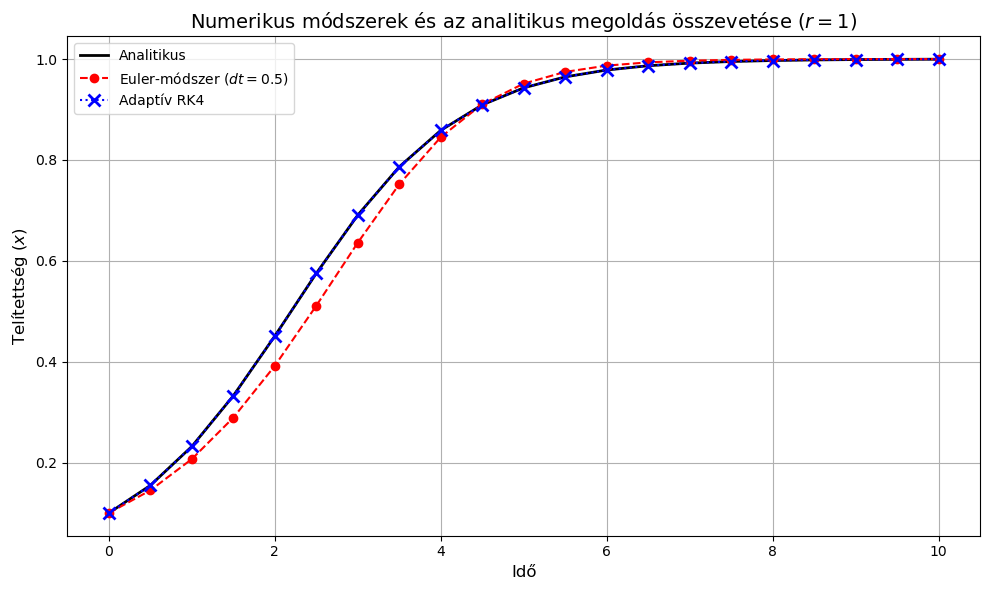

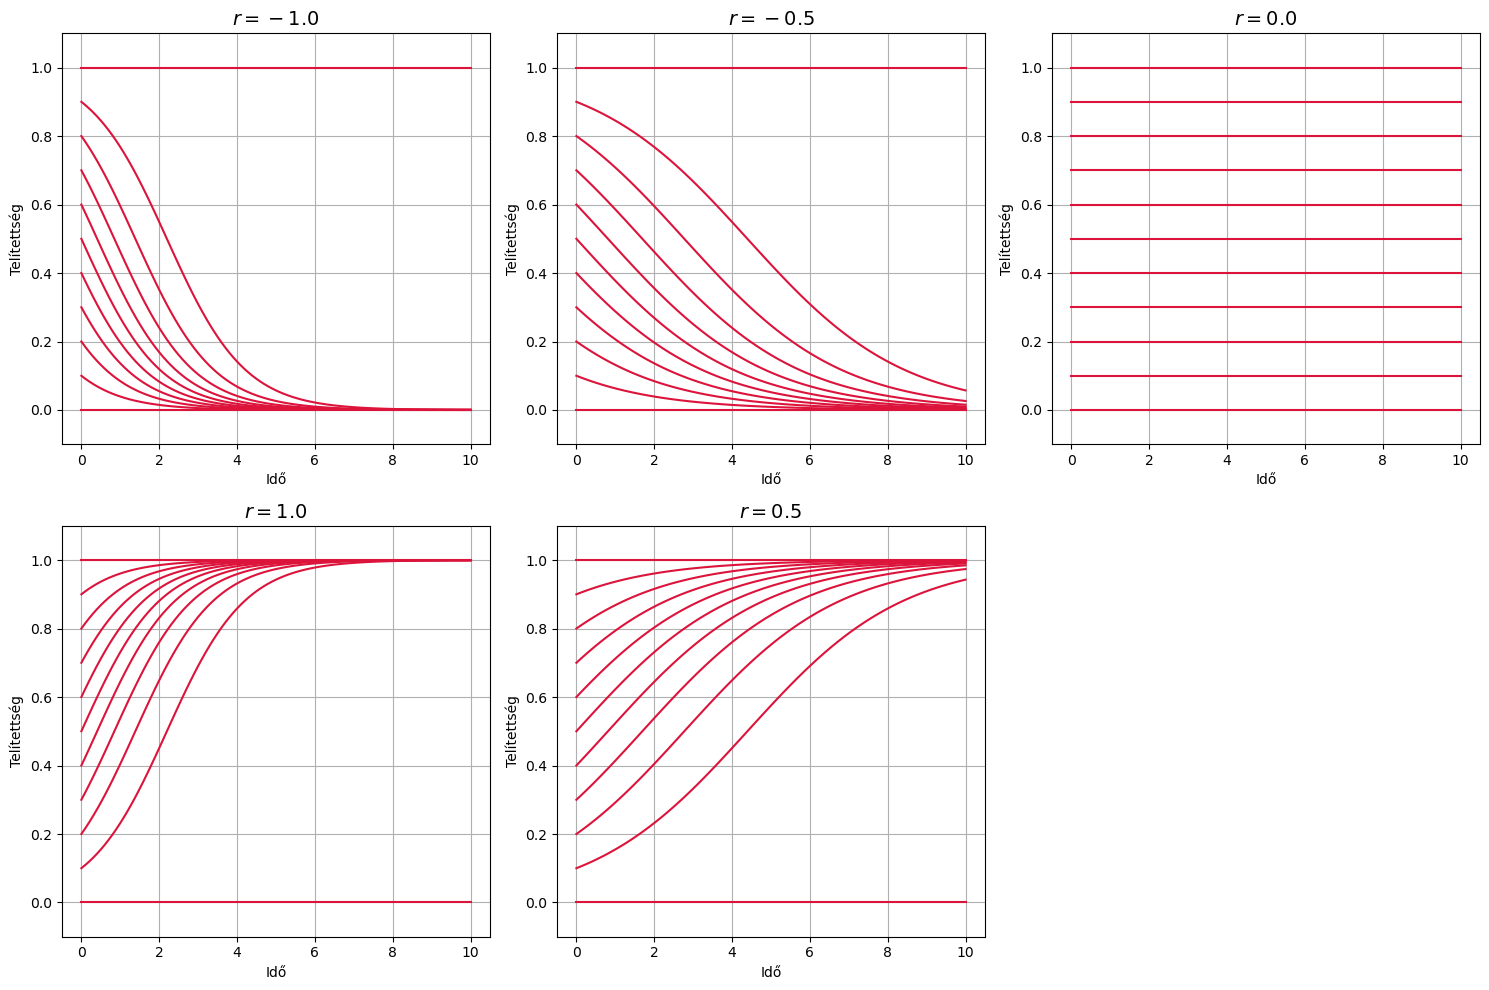

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    data_comp = np.loadtxt("datas/comparison.data", skiprows = 1)
    time = data_comp[:, 0]
    x_exact = data_comp[:, 1]
    x_euler = data_comp[:, 2]
    x_rk = data_comp[:, 3]

    plt.figure(figsize = (10, 6))
    plt.plot(time, x_exact, "k-", linewidth = 2, label = "Analitikus")
    plt.plot(time, x_euler, "ro--", markersize = 6, label = "Euler-módszer ($dt=0.5$)")
    plt.plot(time, x_rk, "bx:", markersize = 8, markeredgewidth=2, label = "Adaptív RK4")

    plt.title("Numerikus módszerek és az analitikus megoldás összevetése ($r=1$)", fontsize = 14)
    plt.xlabel("Idő", fontsize = 12)
    plt.ylabel("Telítettség ($x$)", fontsize = 12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("comparison.pdf")
    plt.show()

except OSError:
    print("Hiba: datas/comparison.data nem található!")


try:
    data_page7 = np.loadtxt("datas/page7.data", skiprows = 1)
    
    r_values = [-1.0, -0.5, 0.0, 1.0, 0.5]
    
    fig, axs = plt.subplots(2, 3, figsize = (15, 10))
    axs = axs.flatten()
    
    for i, r in enumerate(r_values):
        mask = (data_page7[:, 0] == r)
        subset = data_page7[mask]
        
        for x0 in np.unique(subset[:, 1]):
            line_data = subset[subset[:, 1] == x0]
            axs[i].plot(line_data[:, 2], line_data[:, 3], "crimson")
            
        axs[i].set_title(f"$r = {r}$", fontsize = 14)
        axs[i].set_xlabel("Idő")
        axs[i].set_ylabel("Telítettség")
        axs[i].set_ylim([-0.1, 1.1])
        axs[i].grid(True)
    axs[5].axis("off")
    
    plt.tight_layout()
    plt.savefig("page7_reproduction.pdf")
    plt.show()

except OSError:
    print("Hiba: datas/page7.data nem található!")

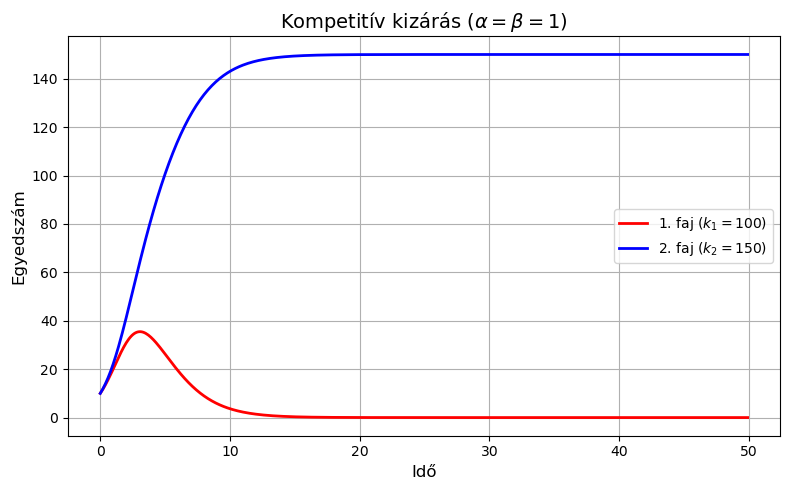

C:\Users\krucs\AppData\Local\Temp\ipykernel_18012\2411334333.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis", 3)


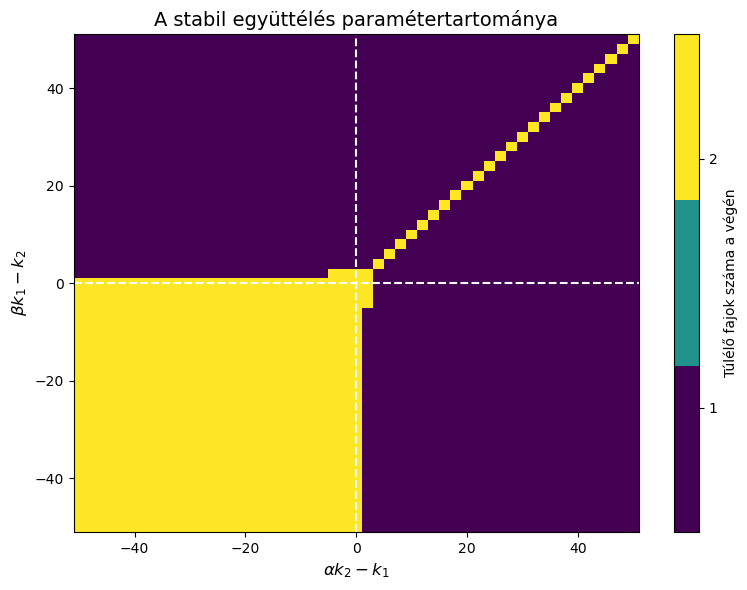

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    data_exc = np.loadtxt("datas/exclusion.data", skiprows = 1)
    t = data_exc[:, 0]
    n1 = data_exc[:, 1]
    n2 = data_exc[:, 2]

    plt.figure(figsize = (8, 5))
    plt.plot(t, n1, "r-", linewidth = 2, label = "1. faj ($k_1=100$)")
    plt.plot(t, n2, "b-", linewidth = 2, label = "2. faj ($k_2=150$)")
    
    plt.title("Kompetitív kizárás ($\\alpha=\\beta=1$)", fontsize = 14)
    plt.xlabel("Idő", fontsize = 12)
    plt.ylabel("Egyedszám", fontsize = 12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("competitive_exclusion.pdf")
    plt.show()

except OSError:
    print("Hiba: datas/exclusion.data nem található!")

try:
    data_co = np.loadtxt("datas/coexistence.data", skiprows = 1)
    X = data_co[:, 0]
    Y = data_co[:, 1]
    Survivors = data_co[:, 2]

    X_unique = np.unique(X)
    Y_unique = np.unique(Y)
    Z = Survivors.reshape(len(X_unique), len(Y_unique)).T

    plt.figure(figsize = (8, 6))
    
    cmap = plt.cm.get_cmap("viridis", 3)
    c = plt.pcolormesh(X_unique, Y_unique, Z, shading = "auto", cmap = cmap, vmin = 0.5, vmax = 2.5)
    
    plt.axhline(0, color = "white", linestyle = "--", linewidth = 1.5)
    plt.axvline(0, color = "white", linestyle = "--", linewidth = 1.5)
    
    plt.colorbar(c, ticks=[1, 2], label = "Túlélő fajok száma a végén")
    plt.title("A stabil együttélés paramétertartománya", fontsize = 14)
    plt.xlabel("$\\alpha k_2 - k_1$", fontsize = 12)
    plt.ylabel("$\\beta k_1 - k_2$", fontsize = 12)
    
    plt.tight_layout()
    plt.savefig("coexistence_phase_space.pdf")
    plt.show()

except OSError:
    print("Hiba: datas/coexistence.data nem található!")

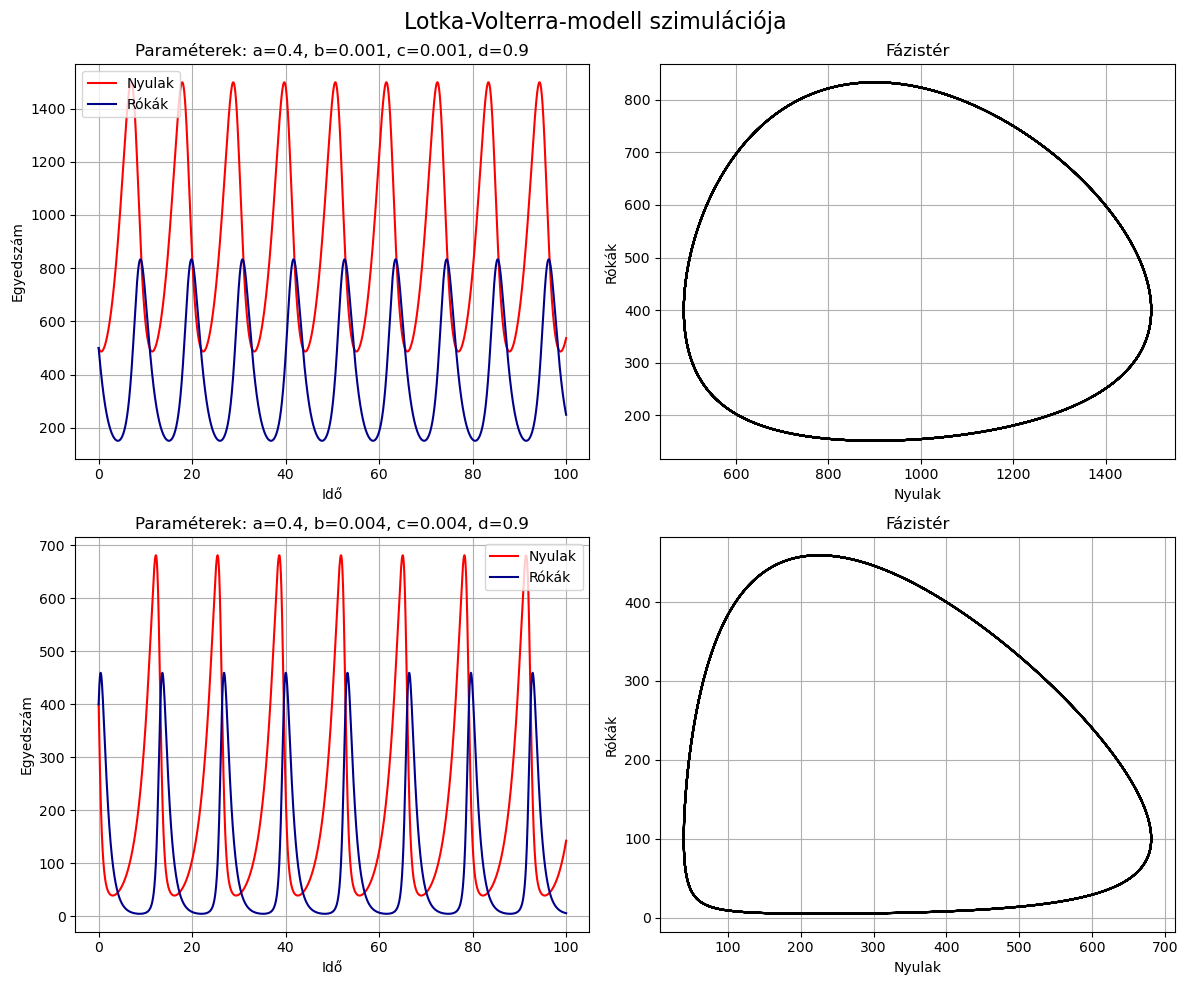

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_lv(filename, ax_time, ax_phase, title_params):
    try:
        data = np.loadtxt(filename, skiprows=1)
        t = data[:, 0]
        nR = data[:, 1] # nyulak
        nF = data[:, 2] # rókák

        ax_time.plot(t, nR, "r-", label = "Nyulak")
        ax_time.plot(t, nF, "darkblue", label = "Rókák")
        ax_time.set_title(title_params, fontsize = 12)
        ax_time.set_xlabel("Idő", fontsize = 12)
        ax_time.set_ylabel("Egyedszám", fontsize = 12)
        ax_time.legend()
        ax_time.grid(True)

        ax_phase.plot(nR, nF, "k-")
        ax_phase.set_title("Fázistér", fontsize = 12)
        ax_phase.set_xlabel("Nyulak", fontsize = 12)
        ax_phase.set_ylabel("Rókák", fontsize = 12)
        ax_phase.grid(True)
        
    except OSError:
        print(f"Hiba: {filename} nem található!")

fig, axs = plt.subplots(2, 2, figsize = (12, 10))

plot_lv("datas/lv_set1.data", axs[0, 0], axs[0, 1], "Paraméterek: a=0.4, b=0.001, c=0.001, d=0.9")
plot_lv("datas/lv_set2.data", axs[1, 0], axs[1, 1], "Paraméterek: a=0.4, b=0.004, c=0.004, d=0.9")

plt.suptitle("Lotka-Volterra-modell szimulációja", fontsize = 16)
plt.tight_layout()
plt.savefig("lotka_volterra_simulation.pdf")
plt.show()

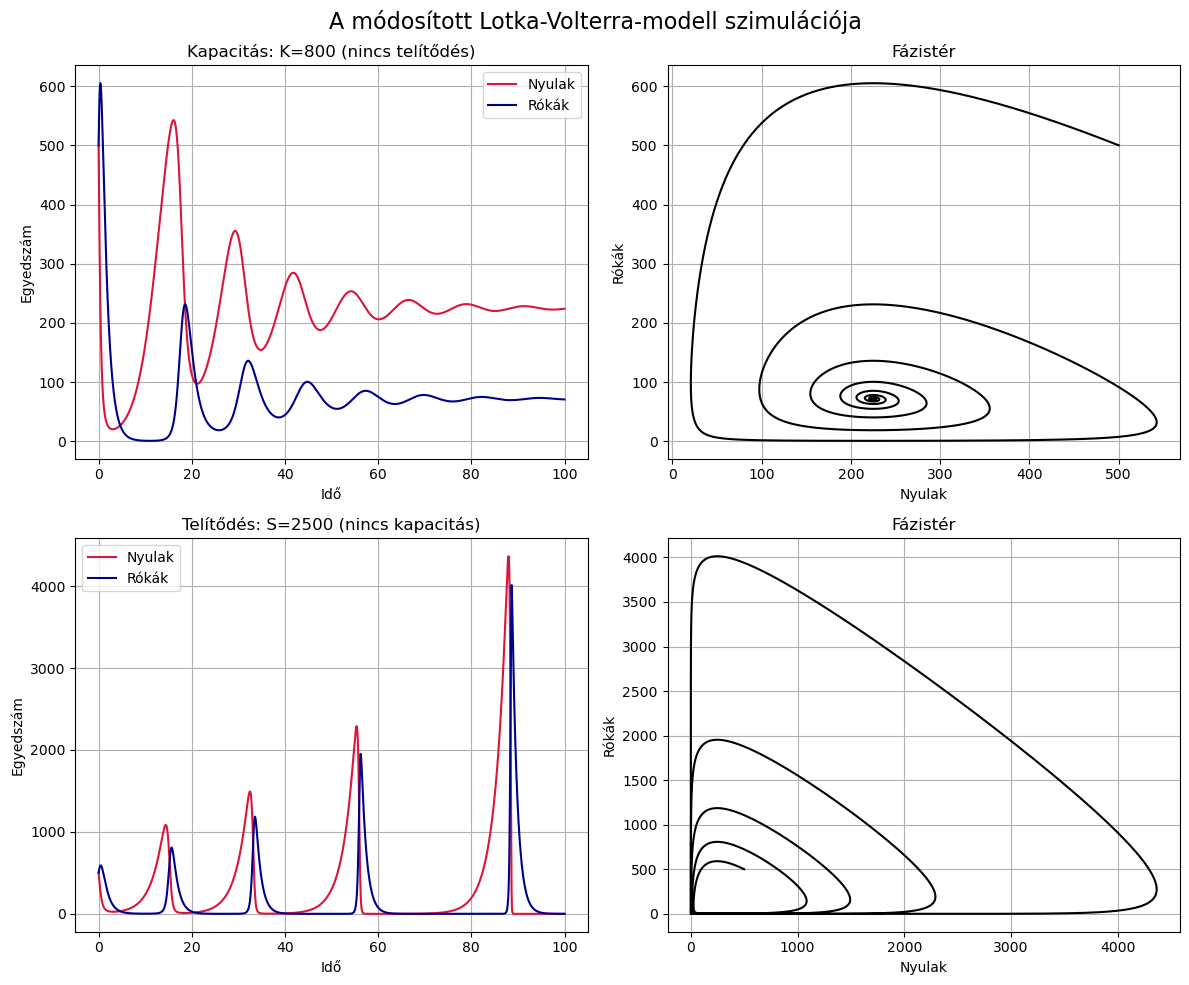

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_mod_lv(filename, ax_time, ax_phase, title_params):
    try:
        data = np.loadtxt(filename, skiprows = 1)
        t = data[:, 0]
        nR = data[:, 1]
        nF = data[:, 2]

        ax_time.plot(t, nR, "crimson", label = "Nyulak")
        ax_time.plot(t, nF, "darkblue", label = "Rókák")
        ax_time.set_title(title_params, fontsize = 12)
        ax_time.set_xlabel("Idő", fontsize = 12)
        ax_time.set_ylabel("Egyedszám", fontsize = 12)
        ax_time.legend()
        ax_time.grid(True)


        ax_phase.plot(nR, nF, "k-", linewidth = 1.5)
        ax_phase.set_title("Fázistér", fontsize = 12)
        ax_phase.set_xlabel("Nyulak", fontsize = 12)
        ax_phase.set_ylabel("Rókák", fontsize = 12)
        ax_phase.grid(True)

        
    except OSError:
        print(f"Hiba: {filename} nem található!")

fig, axs = plt.subplots(2, 2, figsize = (12, 10))

plot_mod_lv("datas/mod_lv_K.data", axs[0, 0], axs[0, 1], "Kapacitás: K=800 (nincs telítődés)")
plot_mod_lv("datas/mod_lv_S.data", axs[1, 0], axs[1, 1], "Telítődés: S=2500 (nincs kapacitás)")

plt.suptitle("A módosított Lotka-Volterra-modell szimulációja", fontsize = 16)
plt.tight_layout()
plt.savefig("mod_lotka_volterra.pdf")
plt.show()

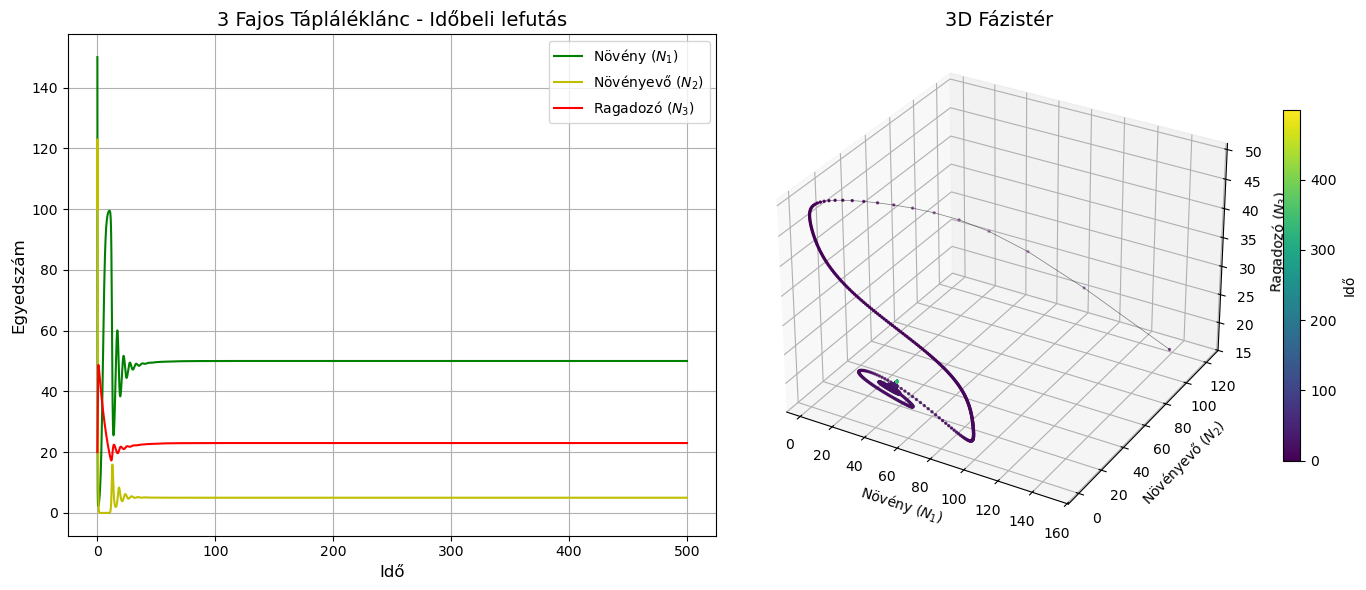

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

try:
    data = np.loadtxt("datas/food_chain.data", skiprows = 1)
    t = data[:, 0]
    n1 = data[:, 1] # növény
    n2 = data[:, 2] # növényevő
    n3 = data[:, 3] # ragadozó

    fig = plt.figure(figsize = (14, 6))

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.plot(t, n1, "g-", label = "Növény ($N_1$)")
    ax1.plot(t, n2, "y-", label = "Növényevő ($N_2$)")
    ax1.plot(t, n3, "r-", label = "Ragadozó ($N_3$)")
    ax1.set_title("3 fajos tápláléklánc időbeli lefutása", fontsize = 14)
    ax1.set_xlabel("Idő", fontsize = 12)
    ax1.set_ylabel("Egyedszám", fontsize =  12)
    ax1.legend()
    ax1.grid(True)

    ax2 = fig.add_subplot(1, 2, 2, projection = "3d")
    # !!! az idő múlását színátmenettel jelezzük !!!
    c = ax2.scatter(n1, n2, n3, c = t, cmap = "viridis", s = 2)
    ax2.plot(n1, n2, n3, "k-", linewidth = 0.5, alpha = 0.5)
    
    ax2.set_title("3D fázistér", fontsize = 14)
    ax2.set_xlabel("Növény ($N_1$)", fontsize = 12)
    ax2.set_ylabel("Növényevő ($N_2$)", fontsize = 12)
    ax2.set_zlabel("Ragadozó ($N_3$)", fontsize = 12)
    fig.colorbar(c, ax = ax2, label = "Idő", shrink = 0.7)

    plt.tight_layout()
    plt.savefig("food_chain_3species.pdf")
    plt.show()

except OSError:
    print("Hiba: A datas/food_chain.data nem található!")